<a href="https://colab.research.google.com/github/Shree1785/CSL701-CE49-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bhagyashree Shrikrishna Wagle CE3 CE49


Machine Learning Experiment No. 2: Simple Linear Regression using OLS.


Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

Hhhhjhh i9hvh. Vevv9vb vv c e9vo9 v9vk## Objectives

- Understand SLR
- Load/preprocess dataset
- Perform EDA
- Compute OLS coefficients
- Evaluate with SSE, MSE, R²
- Visualize regression and residual plots

## Software Requirements

- Python 3.x
- Jupyter/Colab/VS Code
- Libraries: pandas, numpy, matplotlib, seaborn

## Theory

Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:

ŷ = w₀ + w₁x₁

In matrix form, including the bias/intercept term X₀ = 1:

ŷ = Xw

To find the optimal weight vector ŵ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values ŷ:

SSE = ∑ᵢ₌₁ᴺ (yᵢ − ŷᵢ)² = (y − Xw)ᵀ(y − Xw)

Solving for w analytically yields the normal equation:

ŵ = (XᵀX)⁻¹Xᵀy

Note: The inverse (XᵀX)⁻¹ exists only if the matrix XᵀX is non-singular (i.e., its determinant is non-zero).

Task 1: Import Pandas, NumPy, Matplotlib.pyplot and Seaborn.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Task 2: Load the Auto MPG dataset using pd.read_csv().

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


Task 3: Display dataset information using df.info() and identify missing values using df.isnull().sum().

In [ ]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


Task 4: Select the required columns horsepower and mpg from the dataset.

In [ ]:
df = df[['horsepower', 'mpg']]

print(df.head())

   horsepower   mpg
0       130.0  18.0
1       165.0  15.0
2       150.0  18.0
3       150.0  16.0
4       140.0  17.0


Task 5: Remove rows containing missing values from the selected columns.

In [ ]:
df = df.dropna()

print(df.head())

   horsepower   mpg
0       130.0  18.0
1       165.0  15.0
2       150.0  18.0
3       150.0  16.0
4       140.0  17.0


Task 6: Plot a scatter graph of Horsepower vs MPG.

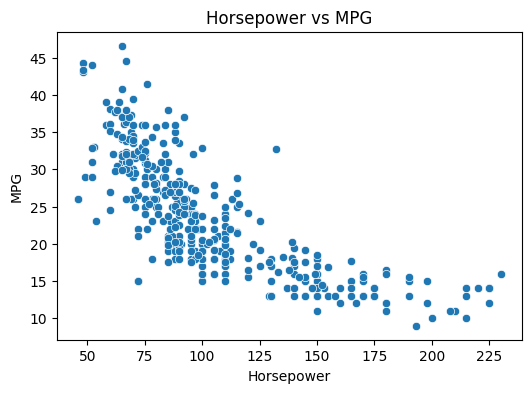

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(x='horsepower', y='mpg', data=df)

plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.show()

Task 7: Calculate the correlation between Horsepower and MPG.

In [ ]:
print("Correlation:")
print(df.corr())

Correlation:
            horsepower       mpg
horsepower    1.000000 -0.778427
mpg          -0.778427  1.000000


Task 8: Add the bias term and calculate the OLS coefficients using the normal equation.

In [ ]:
X = df['horsepower'].values
y = df['mpg'].values

# Add bias term
X_bias = np.c_[np.ones(len(X)), X]

# Normal Equation
w = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

print("Intercept:", w[0])
print("Slope:", w[1])

Intercept: 39.9358610211705
Slope: -0.15784473335365387


Task 9: Predict MPG values and calculate the residuals.

In [ ]:
y_pred = X_bias @ w

residuals = y - y_pred

print("First 10 Predicted MPG:")
print(y_pred[:10])

print("\nFirst 10 Residuals:")
print(residuals[:10])

First 10 Predicted MPG:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]

First 10 Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


Task 10: Calculate SSE, MSE and R² to evaluate the regression model.

In [ ]:
SSE = np.sum(residuals**2)

MSE = np.mean(residuals**2)

SST = np.sum((y - np.mean(y))**2)

R2 = 1 - (SSE / SST)

print("SSE =", SSE)
print("MSE =", MSE)
print("R² =", R2)

SSE = 9385.915871932419
MSE = 23.943662938603108
R² = 0.6059482578894348


Task 11: Plot the regression line for Horsepower vs MPG.

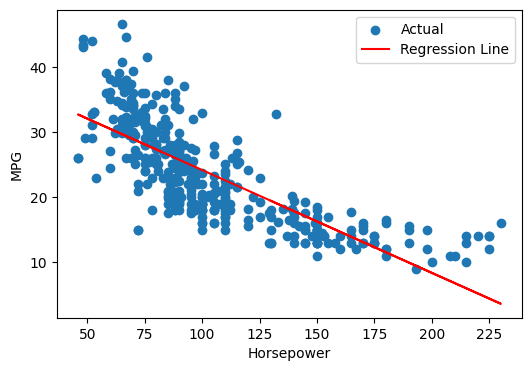

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(X, y, label='Actual')

plt.plot(X, y_pred, color='red', label='Regression Line')

plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.legend()

plt.show()

Task 12: Plot the residual graph of Predicted MPG vs Residuals.

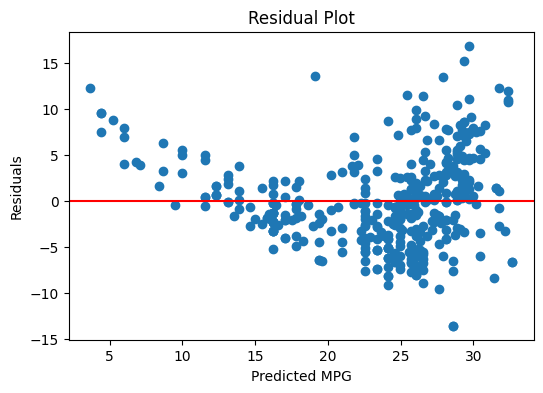

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(y_pred, residuals)

plt.axhline(0, color='red')

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Conclusion:

The experiment successfully implemented Simple Linear Regression using the Ordinary Least Squares (OLS) method. Horsepower showed a negative relationship with MPG, and the model was evaluated using SSE, MSE and R². Regression and residual plots were also generated successfully.